In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TIME_OFFSET = 10800 #ADT to UTC is 3hrs

In [20]:
def process_file(k, input_csv, output_csv):
    print(f"Processing {input_csv}...")

    df = pd.read_csv(input_csv)

    df["timestamp"] = df["frame.time_epoch"] + TIME_OFFSET

    # Sort for IAT calculation
    df = df.sort_values("timestamp")

    df["time_window"] = (df["timestamp"]*k).astype(int) #k tweaks the time window size 
    packet_counts = df.groupby("time_window").size()
    # print(packet_counts)
    print("description:")
    print(packet_counts.describe())

    df["iat"] = df.groupby(["ip.src", "ip.dst"])["timestamp"].diff().fillna(0) #this basically finds the inter-arrival time for src-dst pairs

    has_transaction_id = "modbus.transaction_id" in df.columns

    agg_dict = {
        "packet_count": ("frame.len", "count"),
        "total_bytes": ("frame.len", "sum"),
        "mean_packet_size": ("frame.len", "mean"),
        "std_packet_size": ("frame.len", "std"),
        "iat_mean": ("iat", "mean"),
        "iat_std": ("iat", "std"),
        "min_iat": ("iat", "min"),
        "max_iat": ("iat", "max"),
        "unique_func_codes": ("modbus.func_code", "nunique"),
        "read_count": ("modbus.func_code", lambda x: x.isin([3, 4]).sum()),
        "write_count": ("modbus.func_code", lambda x: x.isin([5, 6, 15, 16]).sum()),
        "exception_count": ("modbus.exception_code", lambda x: x.notna().sum())
    }
    if has_transaction_id:
        agg_dict["unique_transaction_ids"] = ("modbus.transaction_id", "nunique")

    flows = df.groupby(
        ["time_window", "ip.src", "ip.dst"]
    ).agg(**agg_dict).reset_index()

    flows = flows.fillna(0)
    flows["write_ratio"] = np.where(flows["packet_count"] > 0, flows["write_count"] / flows["packet_count"], 0.0)
    if has_transaction_id:
        flows["duplicate_transaction_ids"] = flows["packet_count"] - flows["unique_transaction_ids"]
        flows["transaction_id_ratio"] = np.where(flows["packet_count"] > 0, flows["unique_transaction_ids"] / flows["packet_count"], 0.0)
    else:
        flows["unique_transaction_ids"] = 0
        flows["duplicate_transaction_ids"] = 0
        flows["transaction_id_ratio"] = 0.0
    flows["exception_ratio"] = np.where(flows["packet_count"] > 0, flows["exception_count"] / flows["packet_count"], 0.0)

    packets_per_window = flows.groupby("time_window")["packet_count"].sum().sort_index()

    plt.figure()
    plt.plot(packets_per_window.index - packets_per_window.index.min(), packets_per_window.values)
    plt.xlabel(f"{1000/k:.2f} ms windows")
    plt.ylabel("Total Packets")
    plt.title("Packets per Time Window")
    plt.show()

    # top_ips = flows["ip.dst"].value_counts().head(5).index

    # fig, axes = plt.subplots(len(top_ips), 1, figsize=(10, 4*len(top_ips)), sharex=True)

    # for i, ip in enumerate(top_ips):
    #     ip_data = flows[flows["ip.dst"] == ip]
    #     packets = ip_data.groupby("time_window")["packet_count"].sum().sort_index()

    #     axes[i].plot(packets.index - packets.index.min(), packets.values)
    #     axes[i].set_title(f"Packets per Window for {ip}")
    #     axes[i].set_ylabel("Packets")

    # axes[-1].set_xlabel(f"{1000/k:.2f} ms windows")

    # plt.tight_layout()
    # plt.show()

    flows.to_csv(output_csv, index=False)
    print(f"Saved → {output_csv}\n")

Processing ../train/benign_nw.csv...
description:
count    7085.000000
mean       75.892025
std        90.031639
min         1.000000
25%        50.000000
50%        50.000000
75%        90.000000
max      1292.000000
dtype: float64


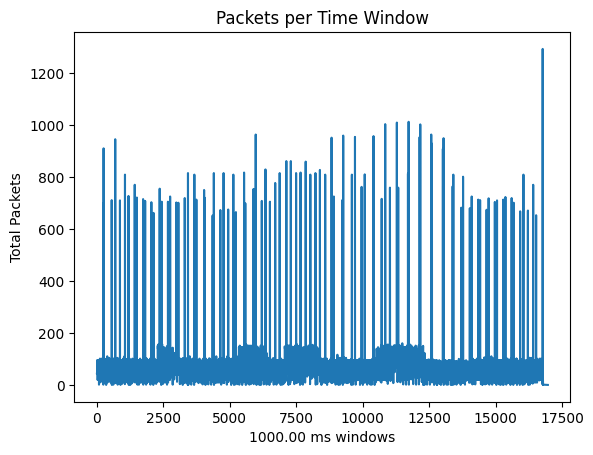

Saved → ../train/1s_benign_flows.csv



In [21]:
process_file(1, "../train/benign_nw.csv", "../train/1s_benign_flows.csv")

Processing ../train/cscada_attack_ssw.csv...
description:
count    14981.000000
mean        77.228289
std        144.291295
min          1.000000
25%         45.000000
50%         50.000000
75%         90.000000
max       8241.000000
dtype: float64


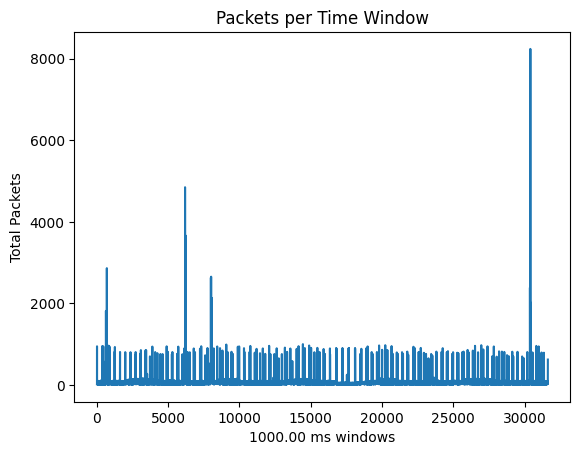

Saved → ../train/1s_cscada_flows.csv



In [22]:
process_file(1, "../train/cscada_attack_ssw.csv", "../train/1s_cscada_flows.csv")

Processing ../train/ext_attack_nw.csv...
description:
count     1881.000000
mean       290.755981
std       1252.626481
min          1.000000
25%         45.000000
50%         45.000000
75%         51.000000
max      20281.000000
dtype: float64


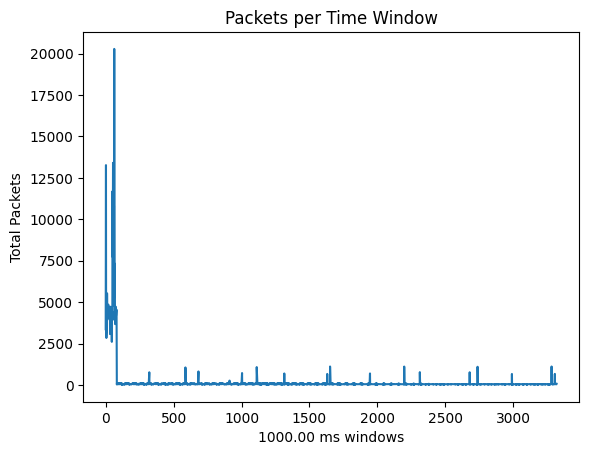

Saved → ../train/1s_external_flows.csv



In [23]:
process_file(1, "../train/ext_attack_nw.csv", "../train/1s_external_flows.csv")

Processing ../train/benign_nw.csv...
description:
count    16602.000000
mean        32.387363
std         56.740018
min          1.000000
25%         11.000000
50%         28.000000
75%         40.000000
max        959.000000
dtype: float64


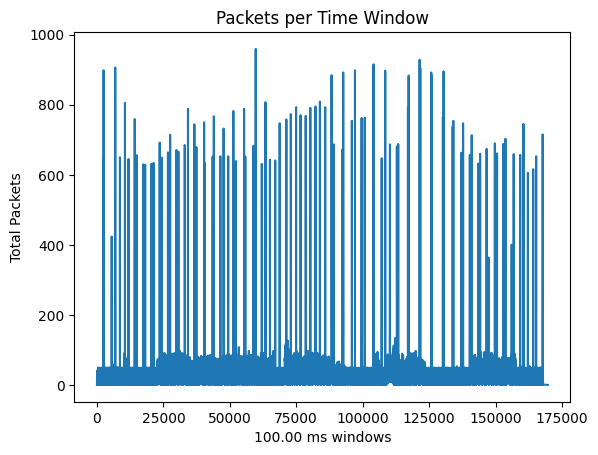

Saved → ../train/100ms_benign_flows.csv



In [24]:
process_file(10, "../train/benign_nw.csv", "../train/100ms_benign_flows.csv") #this is for one second windows

Processing ../train/cscada_attack_ssw.csv...
description:
count    38496.000000
mean        30.053954
std         71.096426
min          1.000000
25%         11.000000
50%         22.000000
75%         35.000000
max       2716.000000
dtype: float64


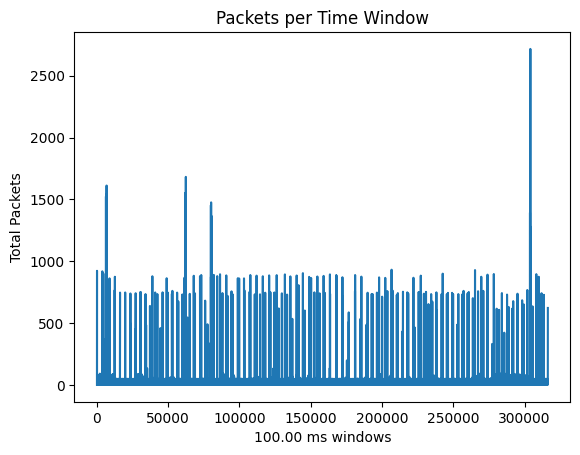

Saved → ../train/100ms_cscada_flows.csv



In [25]:
process_file(10, "../train/cscada_attack_ssw.csv", "../train/100ms_cscada_flows.csv")

Processing ../train/ext_attack_nw.csv...
description:
count     1881.000000
mean       290.755981
std       1252.626481
min          1.000000
25%         45.000000
50%         45.000000
75%         51.000000
max      20281.000000
dtype: float64


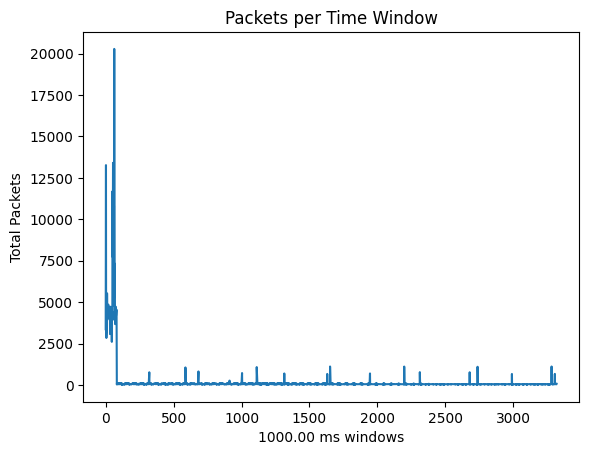

Saved → ../train/1000ms_external_flows.csv



In [26]:
process_file(1, "../train/ext_attack_nw.csv", "../train/1000ms_external_flows.csv")